# S-PersistenceBackground

Posterior distributions of within-state persistence metrics from 225 resampled posterior trees (correlateSet2enforced, burnin already removed).

**Figure S-PersistenceDistributions:**
- **A** — Total branch time per state (violin, 95% HPD)
- **B** — Branch time per introduction (violin, 95% HPD)
- **C** — Number of introductions per state (violin, 95% HPD)

**Figure S-PredictorCollinearity:**
- Spearman correlation matrix of log-transformed network predictors

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats

for font in ['Arial', 'Helvetica', 'DejaVu Sans']:
    try:
        matplotlib.font_manager.findfont(font, fallback_to_default=False)
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = [font]
        break
    except ValueError:
        continue

plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

PROJ_ROOT = Path('../..').resolve()
PAPER_DIR = PROJ_ROOT / 'paper' / 'final'
FINAL_DIR = PAPER_DIR
BEAST_DIR = PAPER_DIR / 'analysis/beast'
_CORR2_DIR = BEAST_DIR / 'phylogeography/correlateSet2e'
TREE_FILE = _CORR2_DIR / 'timeinhomogeneous_correlateSet2enforced_weeklyEpochs_3era_3rateScalar.burninRemovedResampled.trees'
JUMP_FILE = _CORR2_DIR / 'timeinhomogeneous_correlateSet2enforced_weeklyEpochs_3era_3rateScalar.jumpHistory.log'
PREDICTOR_FILE = PAPER_DIR / 'data/covariates/network_predictors_1000nets_16states.csv'
FIG_DIR = FINAL_DIR / 'figures'

TREE_STATE_COLORS = {
    'CA': '#ff7f00', 'TX': '#e41a1c', 'ID': '#7b3294', 'CO': '#2166ac',
    'IA': '#1b9e77', 'MN': '#00838f', 'MI': '#8c6d31', 'OH': '#c51b7d',
    'NM': '#b2abd2', 'WY': '#a6d854', 'SD': '#fc8d62', 'KS': '#ffd92f',
    'UT': '#e5c494', 'NE': '#b3b3b3', 'OK': '#d9d9d9', 'NC': '#66c2a5',
}


def hpd(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = int(np.argmin(widths))
    return sorted_samples[best], sorted_samples[best + interval_size - 1]

## Step 1: Compute branch times from 225 posterior trees

Each branch in the posterior tree is allocated to one or more states based on the BEAST
discrete-trait annotations and Markov jump history recorded in the `history={{...}}` annotation.

**Branch allocation rules:**

1. **No transitions on branch:** The entire branch length is assigned to the child node's
   annotated state (`loc.states`).

2. **One or more transitions on branch:** Transitions are sorted by time (descending, i.e.
   rootward first). The time *between* consecutive transitions is assigned to the destination
   state of the earlier (more rootward) transition. The *residual* time — branch length minus
   the sum of inter-transition segments — represents time before the first transition and after
   the last transition. Because the exact positions of the branch endpoints relative to the
   transitions are unknown, this residual is split equally (50/50) between the origin state of
   the first transition and the destination state of the last transition.

**Note on introduction counts:** Introductions are counted separately from `jumpHistory.log`
(not from the tree annotations), with TX receiving +1 for the root origin.

In [2]:
def parse_trees(tree_path):
    """Parse NEXUS tree file, yield (tree_name, newick_string) per tree."""
    with open(tree_path) as f:
        for line in f:
            line = line.strip()
            if not line.startswith('tree '):
                continue
            m = re.search(r'=\s*(?:\[&[^\]]*\]\s*)?\(', line)
            if not m:
                continue
            name_part = line.split()[1]
            newick = line[m.end() - 1:]
            yield name_part, newick


def compute_branch_times(newick):
    """Walk Newick string, split branches at Markov jump transitions.
    Returns dict of {state: total_branch_time}."""
    state_times = {}

    def add_time(state, t):
        if t > 0:
            state_times[state] = state_times.get(state, 0) + t

    def read_bracket(s, pos):
        assert s[pos] == '['
        depth = 1
        start = pos
        pos += 1
        while pos < len(s) and depth > 0:
            if s[pos] == '[': depth += 1
            elif s[pos] == ']': depth -= 1
            pos += 1
        return s[start:pos], pos

    def parse_node(s, pos):
        if s[pos] == '(':
            pos += 1
            while True:
                pos = parse_node(s, pos)
                if pos < len(s) and s[pos] == ',':
                    pos += 1
                elif pos < len(s) and s[pos] == ')':
                    pos += 1
                    break
                else:
                    break

        if pos < len(s) and s[pos] not in (':', '[', ',', ')', ';'):
            if s[pos] == "'":
                end = s.index("'", pos + 1)
                pos = end + 1
            else:
                while pos < len(s) and s[pos] not in (':', '[', ',', ')', ';'):
                    pos += 1

        node_state = None
        history = []
        while pos < len(s) and s[pos] == '[':
            annotation, pos = read_bracket(s, pos)
            m = re.search(r'loc\.states="(\w+)"', annotation)
            if m:
                node_state = m.group(1)
            hist_match = re.search(r'history=\{\{(.*?)\}\}', annotation)
            if hist_match:
                for hm in re.finditer(r'([\d.Ee+-]+),(\w+),(\w+)', hist_match.group(1)):
                    history.append((float(hm.group(1)), hm.group(2), hm.group(3)))

        branch_length = 0.0
        if pos < len(s) and s[pos] == ':':
            pos += 1
            while pos < len(s) and s[pos] == '[':
                annotation, pos = read_bracket(s, pos)
                m = re.search(r'loc\.states="(\w+)"', annotation)
                if m:
                    node_state = m.group(1)
                hist_match = re.search(r'history=\{\{(.*?)\}\}', annotation)
                if hist_match:
                    for hm in re.finditer(r'([\d.Ee+-]+),(\w+),(\w+)', hist_match.group(1)):
                        history.append((float(hm.group(1)), hm.group(2), hm.group(3)))
            len_start = pos
            while pos < len(s) and s[pos] not in (',', ')', '[', '(', ';'):
                pos += 1
            try:
                branch_length = float(s[len_start:pos])
            except ValueError:
                branch_length = 0.0

        if branch_length > 0 and node_state:
            if not history:
                add_time(node_state, branch_length)
            else:
                history.sort(key=lambda x: x[0], reverse=True)
                inter_time = 0
                for i in range(1, len(history)):
                    seg = history[i - 1][0] - history[i][0]
                    if seg > 0:
                        prev_to = history[i - 1][2]
                        add_time(prev_to, seg)
                        inter_time += seg
                # Residual time (before first and after last transition) split 50/50
                remaining = branch_length - inter_time
                first_from = history[0][1]
                last_to = history[-1][2]
                add_time(first_from, remaining / 2)
                add_time(last_to, remaining / 2)

        return pos

    parse_node(newick, 0)
    return state_times


print('Parsing 225 posterior trees...')
all_rows = []
for i, (tree_name, newick) in enumerate(parse_trees(str(TREE_FILE))):
    state_times = compute_branch_times(newick)
    for state, t in state_times.items():
        all_rows.append({'tree': tree_name, 'state': state, 'branch_time': t})
    if (i + 1) % 25 == 0:
        print(f'  {i + 1} trees parsed...')

bt_df = pd.DataFrame(all_rows)
n_trees = bt_df['tree'].nunique()
states_found = sorted(bt_df['state'].unique())
print(f'Done: {n_trees} trees, {len(states_found)} states: {states_found}')


Parsing 225 posterior trees...
  25 trees parsed...
  50 trees parsed...
  75 trees parsed...
  100 trees parsed...
  125 trees parsed...
  150 trees parsed...
  175 trees parsed...
  200 trees parsed...
  225 trees parsed...
Done: 225 trees, 16 states: ['CA', 'CO', 'IA', 'ID', 'KS', 'MI', 'MN', 'NC', 'NE', 'NM', 'OH', 'OK', 'SD', 'TX', 'UT', 'WY']


## Step 2: Extract introduction counts from jump history

In [3]:
# Build mapping from MCMC iteration to jump history row
print('Loading jump history...')
jump_rows = {}
with open(JUMP_FILE) as f:
    for line in f:
        if line.startswith('#') or line.startswith('state'):
            continue
        parts = line.strip().split('\t')
        if len(parts) >= 3:
            iteration = int(parts[0])
            jump_rows[iteration] = parts[2]

print(f'  {len(jump_rows)} jump history rows loaded')

# Extract tree iterations from tree names
tree_names = sorted(bt_df['tree'].unique())
tree_iterations = {name: int(name.replace('STATE_', '')) for name in tree_names}
print(f'  Tree iterations: {sorted(tree_iterations.values())[:5]} ... {sorted(tree_iterations.values())[-5:]}')

# Count introductions per state per tree
_JUMP_PATTERN = re.compile(r'\{1,([\d.]+),(\w+),(\w+)\}')

intro_rows = []
matched = 0
for tree_name in tree_names:
    iteration = tree_iterations[tree_name]
    if iteration not in jump_rows:
        print(f'  WARNING: no jump history for iteration {iteration}')
        continue
    matched += 1
    history_str = jump_rows[iteration]
    intro_counts = {}
    for m in _JUMP_PATTERN.finditer(history_str):
        dest = m.group(3)
        intro_counts[dest] = intro_counts.get(dest, 0) + 1
    # TX root origin
    intro_counts['TX'] = intro_counts.get('TX', 0) + 1
    for state, count in intro_counts.items():
        intro_rows.append({'tree': tree_name, 'state': state, 'n_introductions': count})

intro_df = pd.DataFrame(intro_rows)
print(f'  Matched {matched}/{len(tree_names)} trees to jump history')

# Merge
df = bt_df.merge(intro_df, on=['tree', 'state'], how='left')
df['n_introductions'] = df['n_introductions'].fillna(0).astype(int)
df['bt_per_intro'] = df['branch_time'] / df['n_introductions'].replace(0, np.nan)

# Save raw data
out_csv = FIG_DIR / 'persistence_branch_times_225trees.csv'
df.to_csv(out_csv, index=False)
print(f'  Saved {out_csv}')

# Summary
print(f'\n=== Summary (median [95% HPD]) ===')
for state in sorted(df['state'].unique()):
    sub = df[df['state'] == state]
    bt = sub['branch_time'].values
    ni = sub['n_introductions'].values
    bpi = sub['bt_per_intro'].dropna().values
    bt_lo, bt_hi = hpd(bt)
    ni_lo, ni_hi = hpd(ni)
    print(f'  {state:>3}: BT={np.median(bt):.2f} [{bt_lo:.2f},{bt_hi:.2f}]  '
          f'intros={np.median(ni):.0f} [{ni_lo:.0f},{ni_hi:.0f}]  '
          f'BT/intro={np.median(bpi):.2f}  '
          f'mean_BT={np.mean(bt):.2f}  mean_intros={np.mean(ni):.1f}')

Loading jump history...
  100001 jump history rows loaded
  Tree iterations: [40000, 80000, 120000, 160000, 200000] ... [8840000, 8880000, 8920000, 8960000, 9000000]
  Matched 225/225 trees to jump history
  Saved /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/figures/persistence_branch_times_225trees.csv

=== Summary (median [95% HPD]) ===
   CA: BT=76.12 [74.11,77.88]  intros=2 [1,2]  BT/intro=38.14  mean_BT=76.10  mean_intros=1.9
   CO: BT=10.40 [9.84,11.30]  intros=7 [5,9]  BT/intro=1.47  mean_BT=10.43  mean_intros=7.3
   IA: BT=1.89 [1.70,2.14]  intros=1 [1,2]  BT/intro=1.87  mean_BT=1.90  mean_intros=1.1
   ID: BT=20.49 [19.76,21.18]  intros=6 [5,7]  BT/intro=3.40  mean_BT=20.49  mean_intros=6.1
   KS: BT=0.49 [0.34,0.72]  intros=8 [6,9]  BT/intro=0.06  mean_BT=0.51  mean_intros=7.7
   MI: BT=4.60 [4.23,5.00]  intros=4 [2,13]  BT/intro=1.19  mean_BT=4.59  mean_intros=5.0
   MN: BT=2.44 [2.15,2.82]  intros=7 [4,9]  BT/intro=0.37  mean_BT=2.46  mean_intros=6.8


## Step 3: Figures

Saved S_PersistenceDistributions to /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/figures


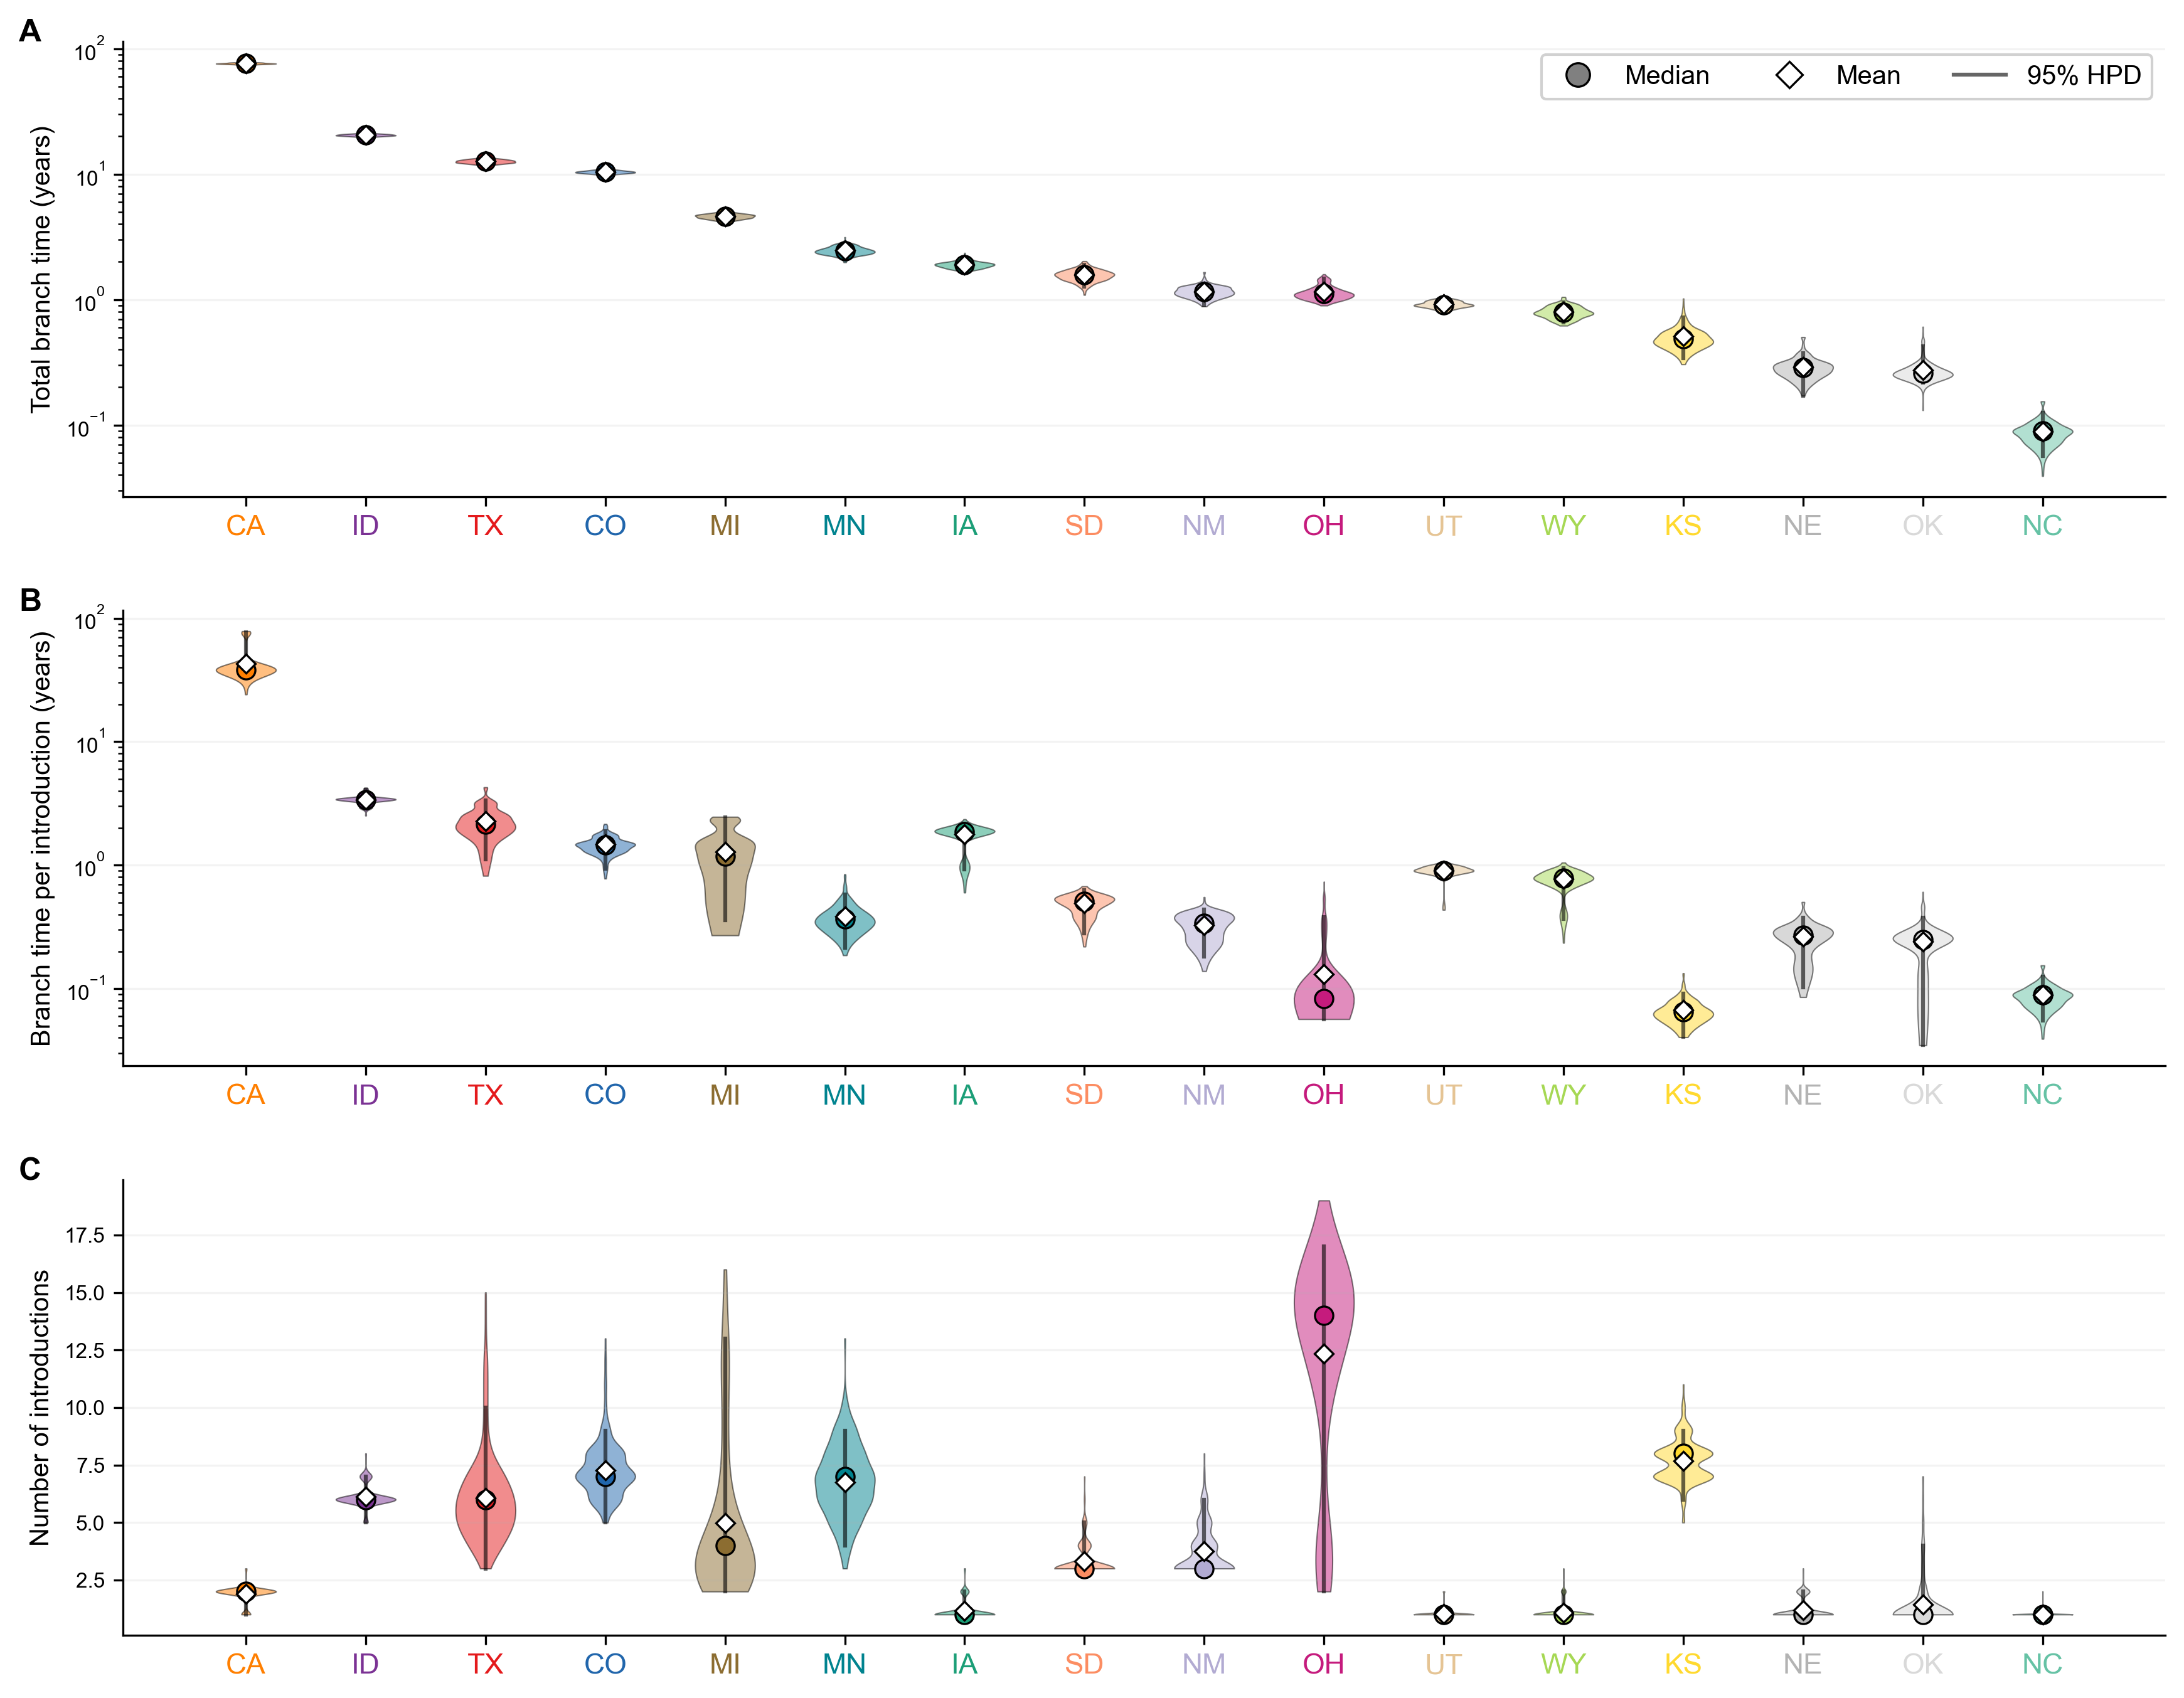

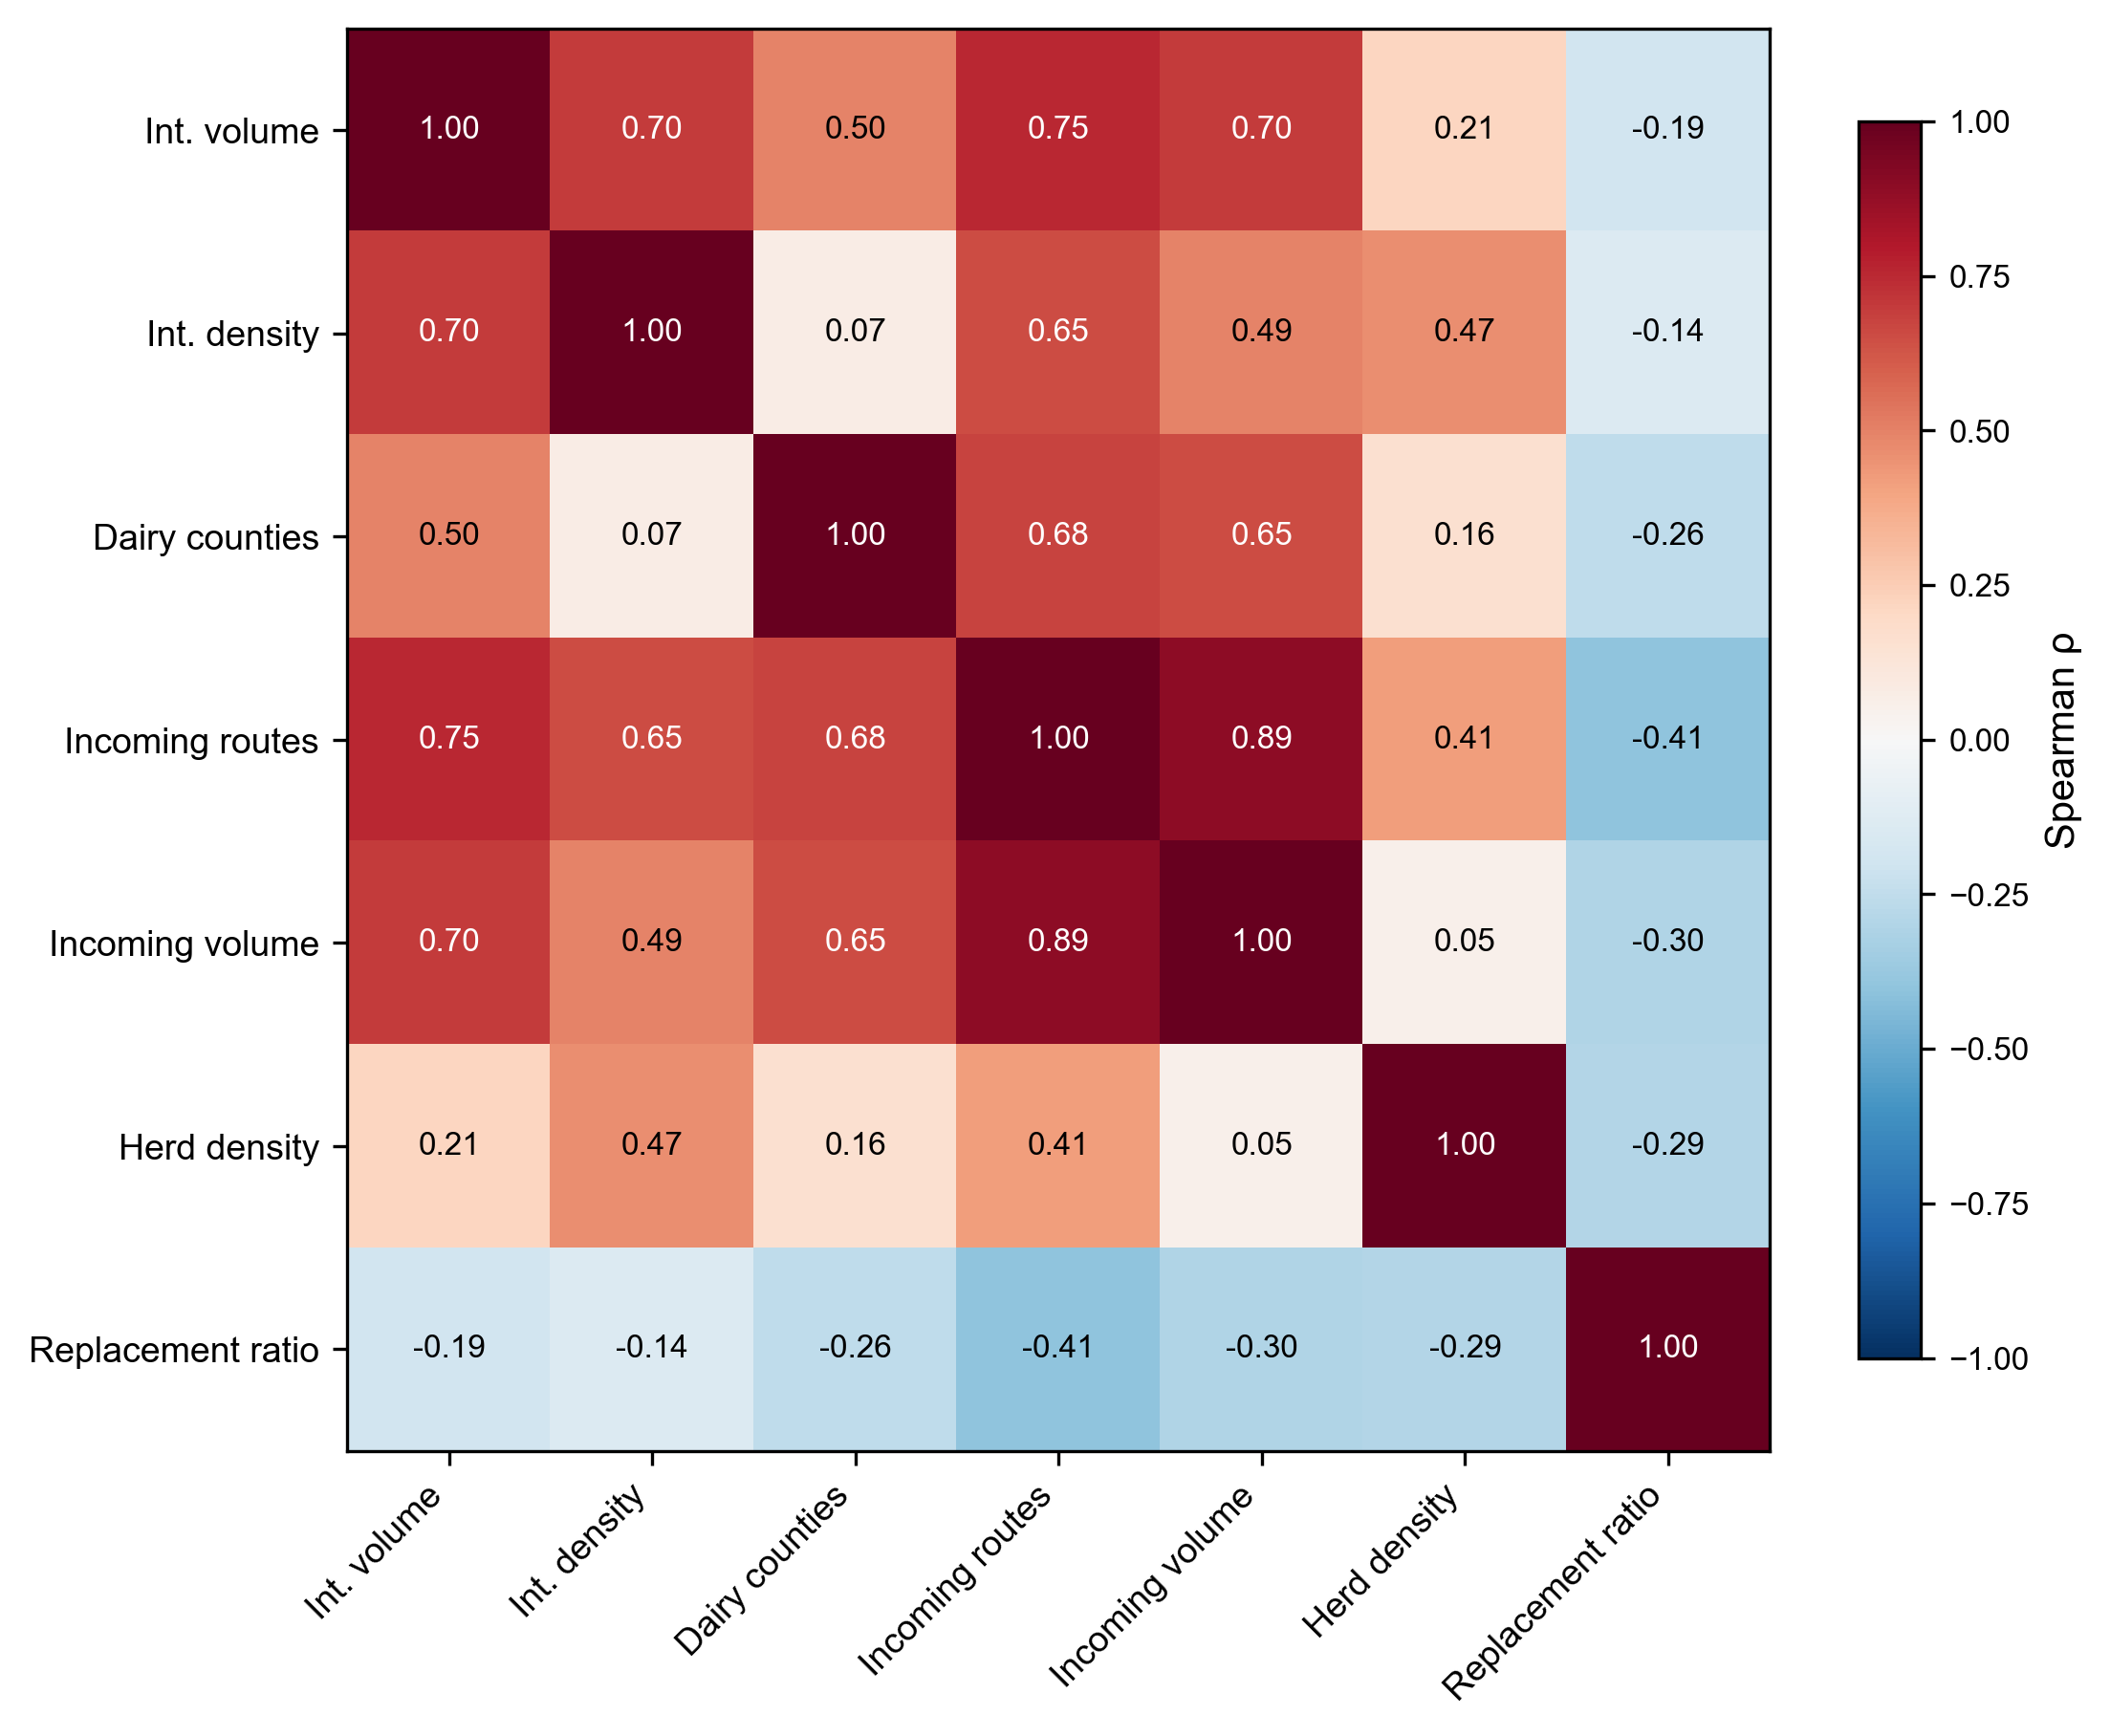

In [4]:
# Sort states by median total branch time (descending)
state_medians = df.groupby('state')['branch_time'].median().sort_values(ascending=False)
state_order = state_medians.index.tolist()
n_states = len(state_order)


def draw_violin_panel(ax, df, value_col, state_order, ylabel, panel_label, log_scale=False):
    """Draw violin plot with median (circle) and mean (diamond) markers."""
    positions = list(range(len(state_order)))
    violin_data = []
    for s in state_order:
        vals = df[df['state'] == s][value_col].dropna().values
        violin_data.append(vals)

    parts = ax.violinplot(violin_data, positions=positions, showextrema=False,
                          showmedians=False, showmeans=False)
    for i, pc in enumerate(parts['bodies']):
        color = TREE_STATE_COLORS.get(state_order[i], '#aaa')
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)

    for i, (s, vals) in enumerate(zip(state_order, violin_data)):
        if len(vals) == 0:
            continue
        color = TREE_STATE_COLORS.get(s, '#aaa')
        med = np.median(vals)
        mean = np.mean(vals)
        lo, hi = hpd(vals)
        ax.plot([i, i], [lo, hi], color='black', lw=1.5, alpha=0.6, zorder=3)
        ax.plot(i, med, 'o', color=color, markersize=7, zorder=5,
                markeredgecolor='black', markeredgewidth=0.8)
        ax.plot(i, mean, 'D', color='white', markersize=5, zorder=5,
                markeredgecolor='black', markeredgewidth=0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels(state_order, fontsize=11)
    for tick_label, s in zip(ax.get_xticklabels(), state_order):
        tick_label.set_color(TREE_STATE_COLORS.get(s, '#aaa'))
    ax.set_ylabel(ylabel, fontsize=10)
    if log_scale:
        ax.set_yscale('log')
    ax.grid(True, alpha=0.15, axis='y')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.text(-0.04, 1.05, panel_label, transform=ax.transAxes, fontsize=12,
            fontweight='bold', va='top', ha='right')


# --- Figure 1: Persistence distributions (A-C) ---
fig1, axes1 = plt.subplots(3, 1, figsize=(14, 11), gridspec_kw={'hspace': 0.25})

draw_violin_panel(axes1[0], df, 'branch_time', state_order,
                  'Total branch time (years)', 'A', log_scale=True)
draw_violin_panel(axes1[1], df, 'bt_per_intro', state_order,
                  'Branch time per introduction (years)', 'B', log_scale=True)
draw_violin_panel(axes1[2], df, 'n_introductions', state_order,
                  'Number of introductions', 'C')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markersize=9, markeredgecolor='black', markeredgewidth=0.8,
           label='Median'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
           markersize=7, markeredgecolor='black', markeredgewidth=0.8,
           label='Mean'),
    Line2D([0], [0], color='black', lw=1.5, alpha=0.6, label='95% HPD'),
]
axes1[0].legend(handles=legend_elements, loc='upper right', ncol=3, fontsize=10,
                framealpha=0.9)

fig1.savefig(FIG_DIR / 'S_PersistenceDistributions.png', dpi=300, bbox_inches='tight')
fig1.savefig(FIG_DIR / 'S_PersistenceDistributions.pdf', bbox_inches='tight')
print(f'Saved S_PersistenceDistributions to {FIG_DIR}')
plt.show()


# --- Figure 2: Predictor collinearity (1000 USAMMv3 realizations) ---
pred = pd.read_csv(PREDICTOR_FILE)

pred_cols = ['mean_internal_volume', 'mean_internal_density', 'n_dairy_counties',
             'mean_external_in_edges', 'mean_external_in_volume',
             'herd_density', 'replacement_ratio']
pred_labels = ['Int. volume', 'Int. density', 'Dairy counties',
               'Incoming routes', 'Incoming volume',
               'Herd density', 'Replacement ratio']

our_states = set(state_order)
pred_sub = pred[pred['state'].isin(our_states)].copy()
log_pred = pred_sub[pred_cols].apply(lambda x: np.log(x + 1))
corr_matrix = log_pred.corr(method='spearman')

fig2, ax_d = plt.subplots(figsize=(8, 7))
im = ax_d.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
for i in range(len(pred_cols)):
    for j in range(len(pred_cols)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax_d.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
ax_d.set_xticks(range(len(pred_labels)))
ax_d.set_xticklabels(pred_labels, fontsize=9, rotation=45, ha='right')
ax_d.set_yticks(range(len(pred_labels)))
ax_d.set_yticklabels(pred_labels, fontsize=9)
fig2.colorbar(im, ax=ax_d, shrink=0.8, label='Spearman ρ')

# fig2.savefig(FIG_DIR / 'S_PredictorCollinearity.png', dpi=300, bbox_inches='tight')
# fig2.savefig(FIG_DIR / 'S_PredictorCollinearity.pdf', bbox_inches='tight')
# print(f'Saved S_PredictorCollinearity to {FIG_DIR}')
plt.show()